# Seismic tomography using PI-INN

In [1]:
import torch, torchvision
import torch.nn as nn
import torch.distributions as distributions
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import time
import os

from INN import RealNVP
from tqdm import tqdm
from neural_network import fully_connected
from torch.autograd import Variable
from torch.utils.data import TensorDataset
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.optim import lr_scheduler
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde


torch.manual_seed(2022)
torch.set_default_dtype(torch.float64)

class Hyperparameters():
    def __init__(self, base_dim, weight_norm, res_blocks, skip, coupling_bn):
        self.base_dim = base_dim
        self.weight_norm = weight_norm
        self.res_blocks = res_blocks
        self.skip = skip
        self.coupling_bn = coupling_bn
        

## Load datasets

In [ ]:
def generate_gaussian_random_fields(kl_values, kl_modes, kl_z, grid_size=101):
    kl_ndim, num_samples = kl_z.shape[1], kl_z.shape[0]
    
    kl_values = kl_values[10:10+kl_ndim]
    kl_modes = kl_modes[:, 10:10+kl_ndim]
    
    fields = np.zeros((num_samples, grid_size, grid_size))
    
    for k in range(num_samples):
        field = np.dot(kl_modes, kl_values * kl_z[k, :])
        fields[k] = field.reshape((grid_size, grid_size))
    
    return fields
device = torch.device("cuda:4")
model_name = 'Seismic_Tomography'

# params for INN
batch_size = 500
hps = Hyperparameters(
    base_dim=128,
    res_blocks=0,
    skip=False,
    weight_norm=False, 
    coupling_bn=False)
        
# optimizer
lr = 1e-3
momentum = 0.9
decay = 0.99

# N-dimensions
ndim_x = 10
ndim_c_u = 12
ndim_z = 2
ndim_x_pad = ndim_c_u + ndim_z - ndim_x

add_pad_noise = 1e-1


data = np.load('data/Gaussian_Fields_data.npz')


kl_values = data['kl_values']
kl_modes = data['kl_modes']
kl_z = data['z']
t_data = data['T_time']
v_data =data['v_fields']



## Construct datasets

In [ ]:
def get_boundary_indices(N_discrete, step=5):
    corner_indices = {
        (0, 0): 0,
        (0, N_discrete-1): N_discrete - 1,
        (N_discrete-1, 0): (N_discrete - 1) * N_discrete,
        (N_discrete-1, N_discrete-1): N_discrete * N_discrete - 1
    }

    bottom_indices = torch.arange(0, N_discrete)  # z = zmin
    top_indices = torch.arange((N_discrete - 1) * N_discrete, N_discrete * N_discrete)  # z = zmax
    left_indices = torch.arange(0, N_discrete * N_discrete, N_discrete)  # x = xmin
    right_indices = torch.arange(N_discrete - 1, N_discrete * N_discrete, N_discrete)  # x = xmax

    selected_bottom_indices = bottom_indices[::step].tolist() + [bottom_indices[-1].item()]
    selected_top_indices = top_indices[::step].tolist() + [top_indices[-1].item()]
    selected_left_indices = left_indices[::step].tolist() + [left_indices[-1].item()]
    selected_right_indices = right_indices[::step].tolist() + [right_indices[-1].item()]

    selected_bottom_indices = list(set(selected_bottom_indices) - set(corner_indices.values()))
    selected_top_indices = list(set(selected_top_indices) - set(corner_indices.values()))
    selected_left_indices = list(set(selected_left_indices) - set(corner_indices.values()))
    selected_right_indices = list(set(selected_right_indices) - set(corner_indices.values()))

    boundary_indices = sorted(selected_bottom_indices + selected_top_indices +
                              selected_left_indices + selected_right_indices +
                              list(corner_indices.values()))

    boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]

    return boundary_indices

N_discrete = 101
zmin = -2.; zmax = 2.;
xmin = -2.; xmax = 2.;
h = (xmax - xmin) / (N_discrete - 1)

# Meshgrid points
# .flip(dims=[0])
z_range = torch.arange(zmin, zmax+h, h).flip(dims=[0])
x_range = torch.arange(xmin, xmax+h, h)
zz, xx = torch.meshgrid(z_range, x_range, indexing='ij')
X_f = torch.concat([xx.reshape(-1, 1), zz.reshape(-1, 1)], dim=1).to(device)


boundary_indices = get_boundary_indices(N_discrete, step=1)
boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]

# source points: (0, 0)
sz = 0
sx = 0

# source index
tolx = 1e-6
tolz = 1e-6
sids = int(torch.where((torch.abs(X_f[:, 1] - sz) < tolz) & (torch.abs(X_f[:, 0] - sx) < tolx))[0][0])
sz_idx = sids // N_discrete
sx_idx = sids % N_discrete



print("==>Input dim:")
print("ndim_x:", ndim_x)
print("ndim_x_pad:", ndim_x_pad)
print("==>Output dim:")
print("ndim_c_u:", ndim_c_u)
print("ndim_z:", ndim_z)
print("==> Input Total Dim:", ndim_x + ndim_x_pad)
print("==> Output Total Dim:", ndim_c_u + ndim_z)


# input data
x_data = kl_z

x_train = torch.from_numpy(x_data[0:-2000]).float()
x_test = torch.from_numpy(x_data[-2000:]).float()

# velocity and traveltime data
v_train = torch.from_numpy(v_data[0:-2000]).float().reshape(-1, N_discrete, N_discrete)
v_test = torch.from_numpy(v_data[-2000:]).float().reshape(-1, N_discrete, N_discrete)
t_train = torch.from_numpy(t_data[0:-2000]).float().reshape(-1, N_discrete, N_discrete)
t_test = torch.from_numpy(t_data[-2000:]).float().reshape(-1, N_discrete, N_discrete)

# construct data loader
train_loader = torch.utils.data.DataLoader(TensorDataset(x_train, v_train, t_train), batch_size=batch_size, 
                                           shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(TensorDataset(x_test, v_test, t_test), batch_size=batch_size, 
                                           shuffle=True, drop_last=True)

==>Input dim:
ndim_x: 10
ndim_x_pad: 4
==>Output dim:
ndim_c_u: 12
ndim_z: 2
==> Input Total Dim: 14
==> Output Total Dim: 14


## Network architecture

In [4]:
class Uniform:
    """
    Approximate 1-d uniform distribution with smoothing
    """
    def __init__(self, lb, ub):
        self.lb = lb
        self.ub = ub
        self.prob_in = 1 / (ub - lb)
        
    def sample(self, sample_size):
        return self.lb + (self.ub - self.lb) * torch.rand(sample_size)
    
    def log_prob(self, x):
        epsilon = 0.1
        tol = 1e-4
        
        px = 1/8 * torch.tanh((x+self.ub) / epsilon) + 1/8 * torch.tanh((-x-self.lb) / epsilon) + tol
        log_px = torch.log(px)
        return log_px
    


in_out_dim = ndim_x + ndim_x_pad
latent = distributions.Normal(
    torch.tensor(0.).to(device), torch.tensor(1.).to(device))
prior_kl_z = distributions.Normal(
    torch.tensor(0.).to(device), torch.tensor(1.).to(device))
xpad = distributions.Normal(
    torch.tensor(0.).to(device), torch.tensor(add_pad_noise).to(device))

# INN and NB-Net
INN = RealNVP(in_out_dim, hps=hps).to(device)
NB_Net = fully_connected(units=128, layers=8, in_dim=2, out_dim=ndim_c_u, activation='ReLU').to(device)

# xavier initialziations
params_INN = [p for p in INN.parameters() if p.requires_grad]
for p in params_INN:
    if p.ndimension() == 1:
        p.data = 0.05 * nn.init.xavier_normal_(p.data.unsqueeze(-1)).squeeze(-1).to(device)
    else:
        p.data = 0.05 * nn.init.xavier_normal_(p.data).to(device)
        
# combined params
params_basis = [p for p in NB_Net.parameters() if p.requires_grad]
combined_params = params_INN + params_basis

optimizer = optim.Adam(combined_params, lr=lr, betas=(momentum, decay), eps=1e-7)

# learning rate decay
scheduler = lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.8, verbose=False)

## Loss functions

In [5]:
def equation_loss(v, tau, tau_x, tau_z, T0, T0_x, T0_z):
    res = (T0 * tau_x + tau * T0_x) ** 2 + (T0 * tau_z + tau * T0_z) ** 2 - 1.0 / v ** 2
    return torch.mean(res ** 2)

def source_loss(tau):
    source_tau = tau[:, sz_idx, sx_idx]
    return torch.mean((source_tau - 1)** 2,dim=0)

def log_Px(out_x_xpad, log_det_J):
    out_x_x = out_x_xpad[:, 0:ndim_x]
    out_x_pad = out_x_xpad[:, -ndim_x_pad:]
    
    log_p_x = torch.sum(prior_kl_z.log_prob(out_x_x), dim=1)
    log_p_pad = torch.sum(xpad.log_prob(out_x_pad), dim=1)
    return log_p_x + log_p_pad + log_det_J
    
def independence_loss(out_x, log_det_J, out_x_star, log_det_J_star, normal_dist):
    return torch.mean(torch.square(log_Px(out_x, log_det_J) - log_Px(out_x_star, log_det_J_star) - normal_dist),dim=0)

def rev_loss(x, out_t, t_star, z_star):
    T_obs = t_star
    tau_obs = T_obs.to(device) / T0
    tau_obs[:, sz_idx, sx_idx] = 1
    tau_obs= tau_obs.reshape(batch_size, N_discrete ** 2)
    
    tau_obs = tau_obs.T[boundary_indices].T
    
    out_t_obs =  out_t[boundary_indices]
    
    out_t_pinverse = torch.pinverse(out_t_obs)

    c_infer = tau_obs @ out_t_pinverse.T
    cz_infer = torch.concat([c_infer, z_star], dim=1)

    
    x_xpad = INN(cz_infer, reverse=True)[0]
    x_pred = x_xpad[:, 0:ndim_x]
    return torch.mean(torch.norm(x[:, 0:ndim_x] - x_pred, dim=1) / torch.norm(x[:, 0:ndim_x], dim=1))

def forwardfit_loss(tau,T0,t_star):
    T_obs = t_star.reshape(batch_size, N_discrete ** 2)
    T_fit = (T0*tau).reshape(batch_size, N_discrete ** 2)
    return torch.mean(torch.norm(T_obs - T_fit, dim=1) / torch.norm(x[:, 0:ndim_x], dim=1))

In [ ]:
# collocation points
x_f = Variable(X_f[:, 0:1], requires_grad=True).to(device)
z_f = Variable(X_f[:, 1:], requires_grad=True).to(device)
def calculate_T0(v_train, sx, sz, v_source):
    dist_matrix = torch.sqrt((zz - sz)**2 + (xx - sx)**2).reshape(N_discrete, N_discrete).to(device)

    T0 = dist_matrix.unsqueeze(0) / v_source.unsqueeze(1).unsqueeze(2)  # (batch_size, N_discrete, N_discrete)
    
    T0_x_data = (xx.to(device) - sx) / (T0 * v_source.unsqueeze(1).unsqueeze(2)**2)
    T0_z_data = (zz.to(device) - sz) / (T0 * v_source.unsqueeze(1).unsqueeze(2)**2)

    T0_x = T0_x_data * (T0 != 0)
    T0_z = T0_z_data * (T0 != 0)
    
    return T0, T0_x, T0_z

In [7]:
max_epoch = 3000
epoch = 0

weight_equ = 100
weight_ind = 1.
weight_source = 10.
weight_rev = 10
weight_fit = 1
best_val_loss = 1e+5

load_model = True

if (load_model==False):

    start_time = time.time()

    while epoch < max_epoch:
        epoch += 1
        print('Epoch %d:' % epoch)

        INN.train()
        running_loss = 0.
        running_equ = 0.
        running_source = 0.
        running_rev = 0.
        running_ind = 0.
        running_fit = 0.

        #=========================================================================
        #============================Training Stage===============================
        #=========================================================================

        for batch_idx, (x, v, t) in enumerate(train_loader):

            batch_idx += 1
            x = x.to(device)
            if ndim_x_pad>0:
                x = torch.cat((x, add_pad_noise*torch.randn(batch_size, ndim_x_pad).to(device)), dim=1)
            v_star = v.float().to(device)
            v_source = v_star [:, sz_idx, sx_idx]
            t_star = t.float().to(device)
            z_star = torch.randn(len(x), ndim_z).to(device)
            T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)

            # predict traveltime T = tau x T0
            out_yz = INN(x)[0]
            out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
            out_t = NB_Net(x_f, z_f)
#             print(out_t.shape)
#             print(out_c.shape)
            tau = (out_c @ out_t.T).reshape(batch_size, N_discrete, N_discrete)
            
            
            # 计算tau的梯度
            tau_x_list = []
            tau_z_list = []
            
            for i in range(ndim_c_u):
                tau_t = out_t[i:i+1].T  # 选择第i个分量
                tau_t_x = torch.autograd.grad(tau_t.sum(), x_f, create_graph=True)[0].view(1, -1)
                tau_t_z = torch.autograd.grad(tau_t.sum(), z_f, create_graph=True)[0].view(1, -1)

                tau_x_list.append(tau_t_x)
                tau_z_list.append(tau_t_z)

            tau_x =(out_c @ torch.concat(tau_x_list, dim=0)).reshape( batch_size ,N_discrete, N_discrete)
            tau_z =(out_c @ torch.concat(tau_z_list, dim=0)).reshape( batch_size ,N_discrete, N_discrete)
#             tau_x = (out_c @ torch.concat(tau_x_list, dim=0)).view(-1, N_discrete, N_discrete)
#             tau_z = (out_c @ torch.concat(tau_z_list, dim=0)).view(-1, N_discrete, N_discrete)

            # compute loss terms
            loss_fit = forwardfit_loss(tau,T0,t_star)
#             print(t_star.shape)
#             print(tau.shape)
#             print(T0.shape)
            
            ## equation and source loss terms
            loss_equ = equation_loss(v_star, tau, tau_x, tau_z, T0, T0_x, T0_z)
#             print(loss_equ.shape)
            loss_source = source_loss(tau)
            
#             print(loss_source.shape)
            # independece loss term
            yz = torch.cat((out_yz[:, 0:ndim_c_u], z_star), dim=1)
            out_x_xpad, log_det_J = INN(out_yz, reverse=True)
            out_x_xpad_star, log_det_J_star = INN(yz, reverse=True)
            normal_dist = torch.sum(latent.log_prob(out_z) - latent.log_prob(z_star), dim=1)
            loss_ind = independence_loss(out_x_xpad, log_det_J, out_x_xpad_star, log_det_J_star, normal_dist)
#             print(loss_ind.shape)
            # reverse loss term (just for check)
            loss_rev = rev_loss(x, out_t, t_star, z_star)

            # total loss functions
            loss = weight_equ * loss_equ + weight_source * loss_source + weight_ind * loss_ind + weight_rev * loss_rev + weight_fit * loss_fit

            running_loss += loss.item()
            running_equ += loss_equ.item()
            running_source += loss_source.item()
            running_ind += loss_ind.item()
            running_rev += loss_rev.item()
            running_fit += loss_fit.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()


        mean_loss = running_loss / batch_idx
        mean_equ = running_equ / batch_idx
        mean_source = running_source / batch_idx
        mean_ind = running_ind / batch_idx
        mean_rev = running_rev / batch_idx
        mean_fit = running_fit / batch_idx

        print('===> Average train loss: %.6f,\t equation loss: %.6f,\t source loss: %.6f,\t ind loss: %.6f,\t rev loss: %.6f, fit loss: %.6f' % 
              (mean_loss, mean_equ, mean_source, mean_ind, mean_rev,mean_fit))

        INN.eval()
        running_loss = 0.
        running_equ = 0.
        running_source = 0.
        running_rev = 0.
        running_ind = 0.
        running_fit = 0.

        #=========================================================================
        #============================Validation Stage=============================
        #=========================================================================

        for batch_idx, (x, v, t) in enumerate(test_loader):

            batch_idx += 1
            x = x.to(device)
            if ndim_x_pad>0:
                x = torch.cat((x, add_pad_noise*torch.randn(batch_size, ndim_x_pad).to(device)), dim=1)
            v_star = v.float().to(device)
            v_source = v_star [:, sz_idx, sx_idx]
            t_star = t.float().to(device)
            z_star = torch.randn(len(x), ndim_z).to(device)
            T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)

            # predict traveltime T = tau x T0
            out_yz = INN(x)[0]
            out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
            out_t = NB_Net(x_f, z_f)
#             print(out_t.shape)
#             print(out_c.shape)
            tau = (out_c @ out_t.T).reshape(batch_size, N_discrete, N_discrete)
            
            
            # 计算tau的梯度
            tau_x_list = []
            tau_z_list = []
            
            for i in range(ndim_c_u):
                tau_t = out_t[i:i+1].T  # 选择第i个分量
                tau_t_x = torch.autograd.grad(tau_t.sum(), x_f, create_graph=True)[0].view(1, -1)
                tau_t_z = torch.autograd.grad(tau_t.sum(), z_f, create_graph=True)[0].view(1, -1)

                tau_x_list.append(tau_t_x)
                tau_z_list.append(tau_t_z)

            tau_x =(out_c @ torch.concat(tau_x_list, dim=0)).reshape( batch_size ,N_discrete, N_discrete)
            tau_z =(out_c @ torch.concat(tau_z_list, dim=0)).reshape( batch_size ,N_discrete, N_discrete)
#             tau_x = (out_c @ torch.concat(tau_x_list, dim=0)).view(-1, N_discrete, N_discrete)
#             tau_z = (out_c @ torch.concat(tau_z_list, dim=0)).view(-1, N_discrete, N_discrete)

            # compute loss terms
            loss_fit = forwardfit_loss(tau,T0,t_star)
#             print(t_star.shape)
#             print(tau.shape)
#             print(T0.shape)
            
            ## equation and source loss terms
            loss_equ = equation_loss(v_star, tau, tau_x, tau_z, T0, T0_x, T0_z)
#             print(loss_equ.shape)
            loss_source = source_loss(tau)
            
#             print(loss_source.shape)
            # independece loss term
            yz = torch.cat((out_yz[:, 0:ndim_c_u], z_star), dim=1)
            out_x_xpad, log_det_J = INN(out_yz, reverse=True)
            out_x_xpad_star, log_det_J_star = INN(yz, reverse=True)
            normal_dist = torch.sum(latent.log_prob(out_z) - latent.log_prob(z_star), dim=1)
            loss_ind = independence_loss(out_x_xpad, log_det_J, out_x_xpad_star, log_det_J_star, normal_dist)
#             print(loss_ind.shape)
            # reverse loss term (just for check)
            loss_rev = rev_loss(x, out_t, t_star, z_star)

            # total loss functions
            loss = weight_equ * loss_equ + weight_source * loss_source + weight_ind * loss_ind + weight_rev * loss_rev + weight_fit * loss_fit

            running_loss += loss.item()
            running_equ += loss_equ.item()
            running_source += loss_source.item()
            running_ind += loss_ind.item()
            running_rev += loss_rev.item()
            running_fit += loss_fit.item()
            


        mean_loss = running_loss / batch_idx
        mean_equ = running_equ / batch_idx
        mean_source = running_source / batch_idx
        mean_ind = running_ind / batch_idx
        mean_rev = running_rev / batch_idx
        mean_fit = running_fit / batch_idx

        print('===> Average test loss: %.6f,\t equation loss: %.6f,\t source loss: %.6f,\t ind loss: %.6f,\t rev loss: %.6f, fit loss: %.6f' % 
              (mean_loss, mean_equ, mean_source, mean_ind, mean_rev,mean_fit))

        if best_val_loss > mean_loss:
            best_val_loss = mean_loss
            torch.save(INN, './models/INN2.pt')
            torch.save(NB_Net, './models/NB_Net2.pt')

        scheduler.step()
    print('Time elapsed:', time.time() - start_time)
else:
    INN = torch.load('./models/INN2.pt')
    NB_Net = torch.load('./models/NB_Net2.pt')

In [ ]:
def get_boundary_indices(N_discrete, step=5):

    corner_indices = {
        (0, 0): 0,
        (0, N_discrete-1): N_discrete - 1,
        (N_discrete-1, 0): (N_discrete - 1) * N_discrete,
        (N_discrete-1, N_discrete-1): N_discrete * N_discrete - 1
    }


    bottom_indices = torch.arange(0, N_discrete)  # z = zmin
    top_indices = torch.arange((N_discrete - 1) * N_discrete, N_discrete * N_discrete)  # z = zmax
    left_indices = torch.arange(0, N_discrete * N_discrete, N_discrete)  # x = xmin
    right_indices = torch.arange(N_discrete - 1, N_discrete * N_discrete, N_discrete)  # x = xmax


    selected_bottom_indices = bottom_indices[::step].tolist() + [bottom_indices[-1].item()]
    selected_top_indices = top_indices[::step].tolist() + [top_indices[-1].item()]
    selected_left_indices = left_indices[::step].tolist() + [left_indices[-1].item()]
    selected_right_indices = right_indices[::step].tolist() + [right_indices[-1].item()]


    selected_bottom_indices = list(set(selected_bottom_indices) - set(corner_indices.values()))
    selected_top_indices = list(set(selected_top_indices) - set(corner_indices.values()))
    selected_left_indices = list(set(selected_left_indices) - set(corner_indices.values()))
    selected_right_indices = list(set(selected_right_indices) - set(corner_indices.values()))


    boundary_indices = sorted(selected_bottom_indices + selected_top_indices +
                              selected_left_indices + selected_right_indices +
                              list(corner_indices.values()))


    boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]

    return boundary_indices

N_discrete = 101
zmin = -2.; zmax = 2.;
xmin = -2.; xmax = 2.;
h = (xmax - xmin) / (N_discrete - 1)

# Meshgrid points
# .flip(dims=[0])
z_range = torch.arange(zmin, zmax+h, h).flip(dims=[0])
x_range = torch.arange(xmin, xmax+h, h)
zz, xx = torch.meshgrid(z_range, x_range, indexing='ij')
X_f = torch.concat([xx.reshape(-1, 1), zz.reshape(-1, 1)], dim=1).to(device)

test_size = 2000
# Test data
x_test = torch.from_numpy(x_data[-2000:]).float().to(device)
v_test = torch.from_numpy(v_data[-2000:]).float().reshape(-1, N_discrete, N_discrete).to(device)
t_test = torch.from_numpy(t_data[-2000:]).float().reshape(-1, N_discrete, N_discrete).to(device)

boundary_indices = get_boundary_indices(N_discrete, step=1)
boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]


In [16]:
def test_rev(x, out_t, tau_obs):
    
    
    out_t_pinverse = torch.pinverse(out_t)

    c_infer = tau_obs @ out_t_pinverse.T
    
    z_star = torch.randn(len(x), ndim_z).to(device)
    cz_infer = torch.concat([c_infer, z_star], dim=1)
    

    
    x_xpad = INN(cz_infer, reverse=True)[0]
    x_pred = x_xpad[:, 0:ndim_x]
    return torch.mean(torch.norm(x[:, 0:ndim_x] - x_pred, dim=1) / torch.norm(x[:, 0:ndim_x], dim=1)) , x_pred

running_rev = 0.


#=========================================================================
#============================Validation Stage=============================
#=========================================================================

for batch_idx, (x, v, t) in enumerate(test_loader):

    batch_idx += 1
    x = x.to(device)
    if ndim_x_pad>0:
        x = torch.cat((x, add_pad_noise*torch.randn(batch_size, ndim_x_pad).to(device)), dim=1)
    v_star = v.float().to(device)
    v_source = v_star [:, sz_idx, sx_idx]
    t_star = t.float().to(device)

    T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)
    
    
 
    tau_obs = t_star/ T0
    tau_obs[:, sz_idx, sx_idx] = 1

    # predict traveltime T = tau x T0
    out_yz = INN(x)[0]
    out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
    out_t = NB_Net(x_f, z_f)
    
    loss_fit = forwardfit_loss(tau_obs,T0,t_star)

    tau_obs = tau_obs.reshape(batch_size,-1)
    
    tau_obs = tau_obs.T[boundary_indices].T
    
    out_t = out_t[boundary_indices]

    loss_rev , x_pred= test_rev(x, out_t, tau_obs)


    running_rev += loss_rev.item()
    




mean_rev = running_rev / batch_idx


print('===> Average  rev loss: %.6f' % 
      ( mean_rev))


print('loss_fit:',loss_fit)

===> Average  rev loss: 0.059969
loss_fit: tensor(0.0025, device='cuda:4')


In [ ]:
def generate_gaussian_random_fields(kl_values, kl_modes, kl_z, grid_size=101):
    kl_ndim, num_samples = kl_z.shape[1], kl_z.shape[0]
    
    kl_values_select = kl_values[10:kl_ndim+10]
    kl_modes_select = kl_modes[:, 10:kl_ndim+10]


    fields = np.zeros((num_samples, N_discrete, N_discrete))

    for k in range(num_samples):
    #     print((kl_values * kl_z[k, :]).shape)
        field = np.dot(kl_modes_select, kl_values_select * kl_z[k, :])
        fields[k] = field.reshape(( N_discrete, N_discrete))
    return fields

x_true = x[:,:ndim_x].cpu().detach().numpy()

x_infer = x_pred[:,:ndim_x].cpu().detach().numpy()

V_true = generate_gaussian_random_fields(kl_values, kl_modes, x_true, grid_size=101)
V_pred = generate_gaussian_random_fields(kl_values, kl_modes, x_infer, grid_size=101)

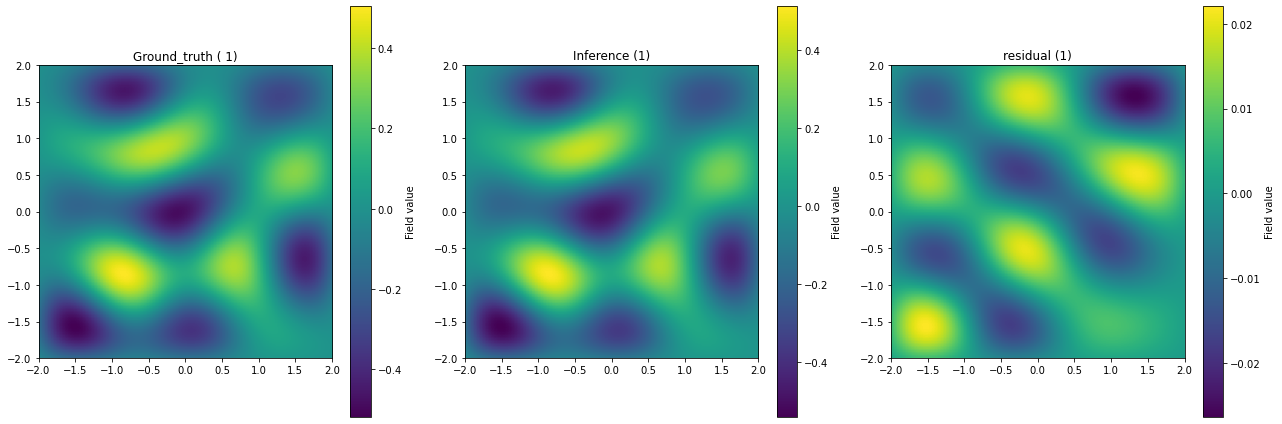

In [ ]:
import matplotlib.pyplot as plt

i = 0

plt.figure(figsize=(18, 6))  


plt.subplot(1, 3, 1)  
plt.imshow(V_true[i], extent=(-2, 2, -2, 2), origin='lower', cmap='viridis')
plt.colorbar(label='Field value')
plt.title(f'Ground_truth ( {i+1})')

plt.subplot(1, 3, 2)  
plt.imshow(V_pred[i], extent=(-2, 2, -2, 2), origin='lower', cmap='viridis')
plt.colorbar(label='Field value')
plt.title(f'Inference ({i+1})')

plt.subplot(1, 3, 3)  
plt.imshow(V_true[i]-V_pred[i], extent=(-2, 2, -2, 2), origin='lower', cmap='viridis')
plt.colorbar(label='Field value')
plt.title(f'residual ({i+1})')

plt.tight_layout()  
plt.show()